# Task 1: Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Fifa.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  str    
 1   Country            19667 non-null  str    
 2   Position           19667 non-null  str    
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  str    
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), str(4)
memory usage: 1.4 MB


In [4]:
df.describe()

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score
count,19667.000000,19667.000000,19667.000000,19667.000000,19667.000000
mean,22.990034,63.225403,70.658718,2.514639,1534.513907
std,4.692410,7.812716,6.489551,7.256974,283.248088
min,15.000000,36.000000,46.000000,0.000000,416.000000
25%,19.000000,58.000000,66.000000,0.325000,1388.000000
50%,22.000000,63.000000,70.000000,0.675000,1549.000000
75%,26.000000,68.000000,75.000000,1.600000,1720.000000
max,44.000000,91.000000,95.000000,190.500000,2324.000000


In [5]:
df.head()


,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


In [6]:
df.tail()

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
19662,Kohei Okuno,Japan,CDM,21,63,71,Gamba Osaka,1.100,1717
19663,Riku Danzaki,Japan,RW,22,64,71,Motherwell,1.200,1607
19664,Hayato Fukushima,Japan,CB,21,59,68,Shonan Bellmare,0.475,1347
19665,Ömer Tokaç,Turkey,LW,18,57,71,Shonan Bellmare,0.220,1481
19666,Ko Sawada,Japan,CAM,28,60,60,Shonan Bellmare,0.250,1636


In [7]:
print(f'Number of columns : {df.shape[1]}')

Number of columns : 9


In [8]:
print(f'Number of rows : {df.shape[0]}')

Number of rows : 19667


# 1. Are there any missing values? How many, and in which columns?

In [9]:
for col in df.columns:
    print(f"Column : {col}")
    print(f"Number of null values: {df[col].isnull().sum()}")
    print("_"*70)
    print()

Column : Name
Number of null values: 0
______________________________________________________________________

Column : Country
Number of null values: 0
______________________________________________________________________

Column : Position
Number of null values: 0
______________________________________________________________________

Column : Age
Number of null values: 0
______________________________________________________________________

Column : Overall_Rating
Number of null values: 0
______________________________________________________________________

Column : Future Potential
Number of null values: 0
______________________________________________________________________

Column : Team
Number of null values: 0
______________________________________________________________________

Column : Value Per M$
Number of null values: 0
______________________________________________________________________

Column : Total_Stats Score
Number of null values: 0
________________________

In [10]:
numerical = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical Features",numerical)

Numerical Features ['Age', 'Overall_Rating', 'Future Potential', 'Value Per M$', 'Total_Stats Score']


In [11]:
categorical = df.select_dtypes(include='object').columns.tolist()
print("Categorical Features:", categorical)

Categorical Features: ['Name', 'Country', 'Position', 'Team']


In [12]:
print(f"Number of duplicates : {df.duplicated().sum()}")

Number of duplicates : 0


# 2. What does the distribution of Value Per M$ look like?
### Skewness : 7.98

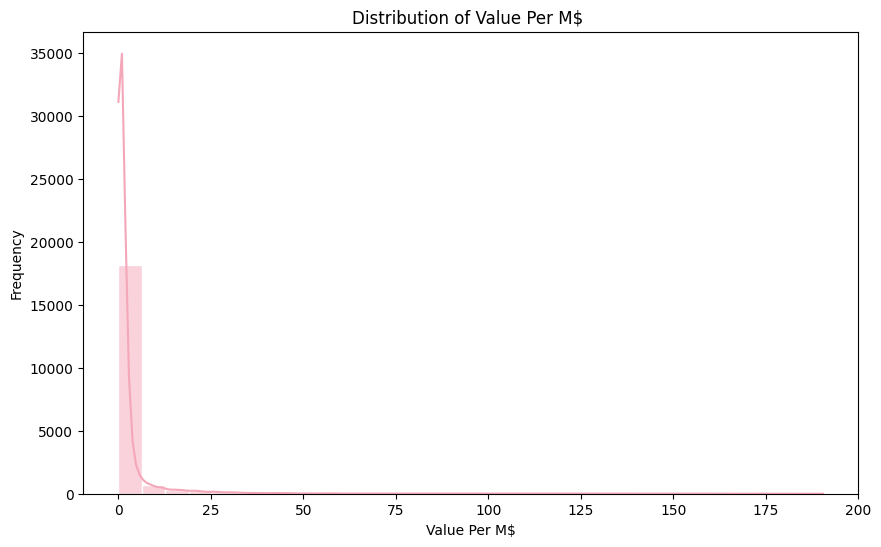

In [13]:
plt.figure(figsize=(10, 6))

sns.histplot(x=df['Value Per M$'], bins=30, kde=True, color='#F4A7B9', edgecolor='white')

plt.title('Distribution of Value Per M$ ')
plt.xlabel('Value Per M$')
plt.ylabel('Frequency')
plt.show()

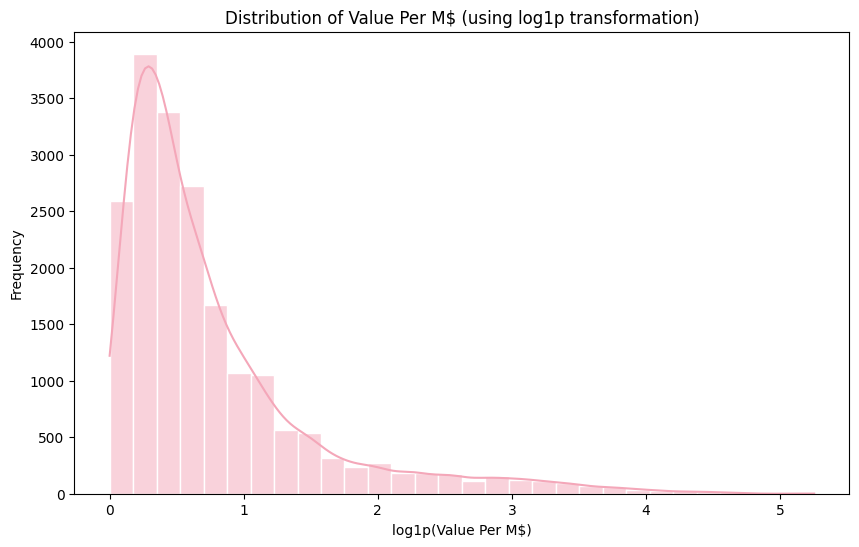

Skewness : 7.983215201865151


In [14]:
plt.figure(figsize=(10, 6))

sns.histplot(x=np.log1p(df['Value Per M$']), bins=30, kde=True, color='#F4A7B9', edgecolor='white')

plt.title('Distribution of Value Per M$ (using log1p transformation)')
plt.xlabel('log1p(Value Per M$)')
plt.ylabel('Frequency')
plt.show()
skewness = df['Value Per M$'].skew()
print("Skewness :", skewness)

# 3. Which numerical features seem most related to Value Per M$?
### Overall_Rating (0.56) is the strongest predictor followed by Future Potential (0.50)

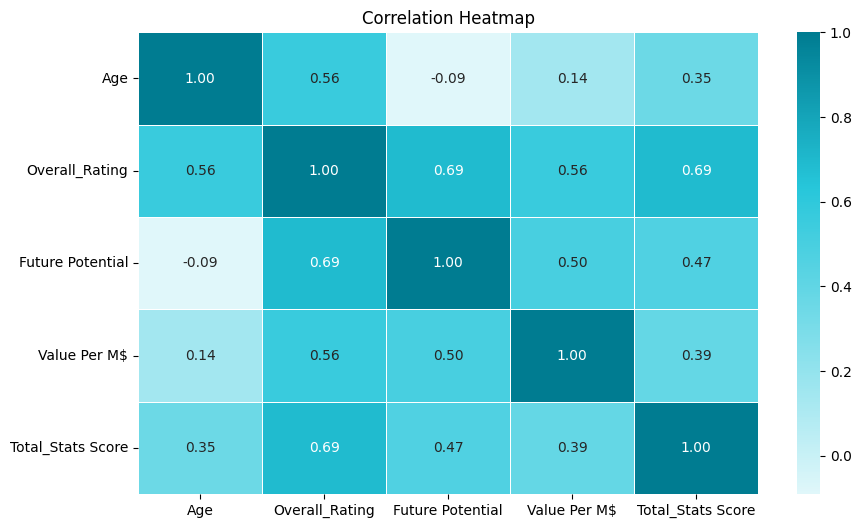

In [15]:

corr = df[numerical].corr()


c_map = LinearSegmentedColormap.from_list(
    "c_map", ["#E0F7FA", "#80DEEA", "#26C6DA", "#007C91"]
)

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap=c_map,
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

# 4.What is the average Overall_Rating per Position?

Average Overall Rating per Position:
 Position
GK     60.987288
CM     62.511767
RB     62.863636
ST     63.087505
LB     63.276794
CB     63.544448
CAM    63.679709
RW     63.718529
RM     63.907731
LWB    64.043333
RWB    64.063973
LM     64.172009
CDM    64.234168
LW     64.345979
CF     66.042857
RF     75.000000
SW     75.000000
Name: Overall_Rating, dtype: float64


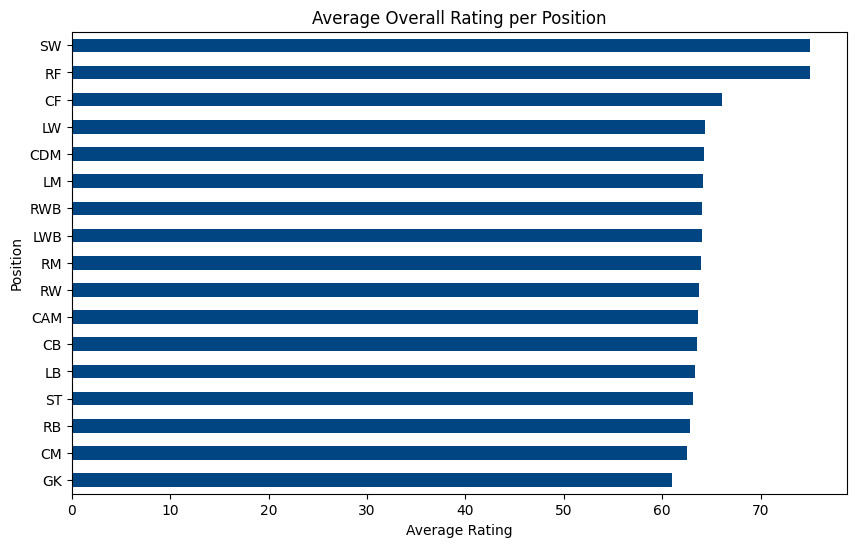

In [16]:
avg_rating = df.groupby('Position')['Overall_Rating'].mean().sort_values(ascending=True)

print("Average Overall Rating per Position:\n", avg_rating)

plt.figure(figsize=(10,6))
avg_rating.plot(kind='barh', color="#014682")
plt.title("Average Overall Rating per Position")
plt.xlabel("Average Rating")
plt.show()

# Task 2: Data Preprocessing

Removes duplicate rows from the dataset to avoid bias and repeated information

Drops rows where price is missing, since price is the target variable and cannot be null

In [17]:

df.drop_duplicates(inplace=True)
df = df.dropna(subset=['Value Per M$'])

### Split the dataset into Train and Test sets (80/20)

Train-Test Split:
I split the dataset into Training (80%) and Testing (20%) sets before performing any preprocessing. This is a critical step to prevent Data Leakage, ensuring that information from the test set does not influence the training process, which allows for a fair evaluation of the model's performance on unseen data.

In [18]:
train, test = train_test_split(df, test_size=0.2, random_state=7)
print(f'Train set : {train.shape} | Test set : {test.shape}')

Train set : (15733, 9) | Test set : (3934, 9)


# 1. Handling Missing Values

In [19]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()

numeric_imputer = SimpleImputer(strategy='median')

train[numeric_cols] = numeric_imputer.fit_transform(train[numeric_cols])
test[numeric_cols] = numeric_imputer.transform(test[numeric_cols])

## Categorical Columns

In [20]:
categorical_cols = train.select_dtypes(include=['object']).columns.tolist()

if len(categorical_cols) > 0:
    categorical_imputer = SimpleImputer(strategy='most_frequent')
    train[categorical_cols] = categorical_imputer.fit_transform(train[categorical_cols])
    test[categorical_cols] = categorical_imputer.transform(test[categorical_cols])

In [21]:
print('Remaining missing values in train : ',train.isnull().sum().sum())
print("_"*70)
print()
for col in train.columns:
    print(f"Column : {col}")
    print(f"Number of null values: {train[col].isnull().sum()}")
    print("_"*70)
    print()

Remaining missing values in train :  0
______________________________________________________________________

Column : Name
Number of null values: 0
______________________________________________________________________

Column : Country
Number of null values: 0
______________________________________________________________________

Column : Position
Number of null values: 0
______________________________________________________________________

Column : Age
Number of null values: 0
______________________________________________________________________

Column : Overall_Rating
Number of null values: 0
______________________________________________________________________

Column : Future Potential
Number of null values: 0
______________________________________________________________________

Column : Team
Number of null values: 0
______________________________________________________________________

Column : Value Per M$
Number of null values: 0
_____________________________________

In [22]:
print('Remaining missing values in test : ',test.isnull().sum().sum())
print("_"*70)
print()
for col in train.columns:
    print(f"Column : {col}")
    print(f"Number of null values: {test[col].isnull().sum()}")
    print("_"*70)
    print()

Remaining missing values in test :  0
______________________________________________________________________

Column : Name
Number of null values: 0
______________________________________________________________________

Column : Country
Number of null values: 0
______________________________________________________________________

Column : Position
Number of null values: 0
______________________________________________________________________

Column : Age
Number of null values: 0
______________________________________________________________________

Column : Overall_Rating
Number of null values: 0
______________________________________________________________________

Column : Future Potential
Number of null values: 0
______________________________________________________________________

Column : Team
Number of null values: 0
______________________________________________________________________

Column : Value Per M$
Number of null values: 0
______________________________________

In [23]:
num_cols = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']

# 2. Detect and handle outliers

In [24]:
bounds = {}
for col in num_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    bounds[col] = (lower_bound, upper_bound)
    outliers_count = train[(train[col] < lower_bound) | (train[col] > upper_bound)].shape[0]
    print()
    print(f"Number of outliers in {col.capitalize()} : {outliers_count}")
    print(f"The IQR for column {col.capitalize()} is: {round(IQR, 2)}")
    print("_"*70)


Number of outliers in Age : 136
The IQR for column Age is: 7.0
______________________________________________________________________

Number of outliers in Overall_rating : 117
The IQR for column Overall_rating is: 10.0
______________________________________________________________________

Number of outliers in Future potential : 97
The IQR for column Future potential is: 9.0
______________________________________________________________________

Number of outliers in Total_stats score : 655
The IQR for column Total_stats score is: 330.0
______________________________________________________________________


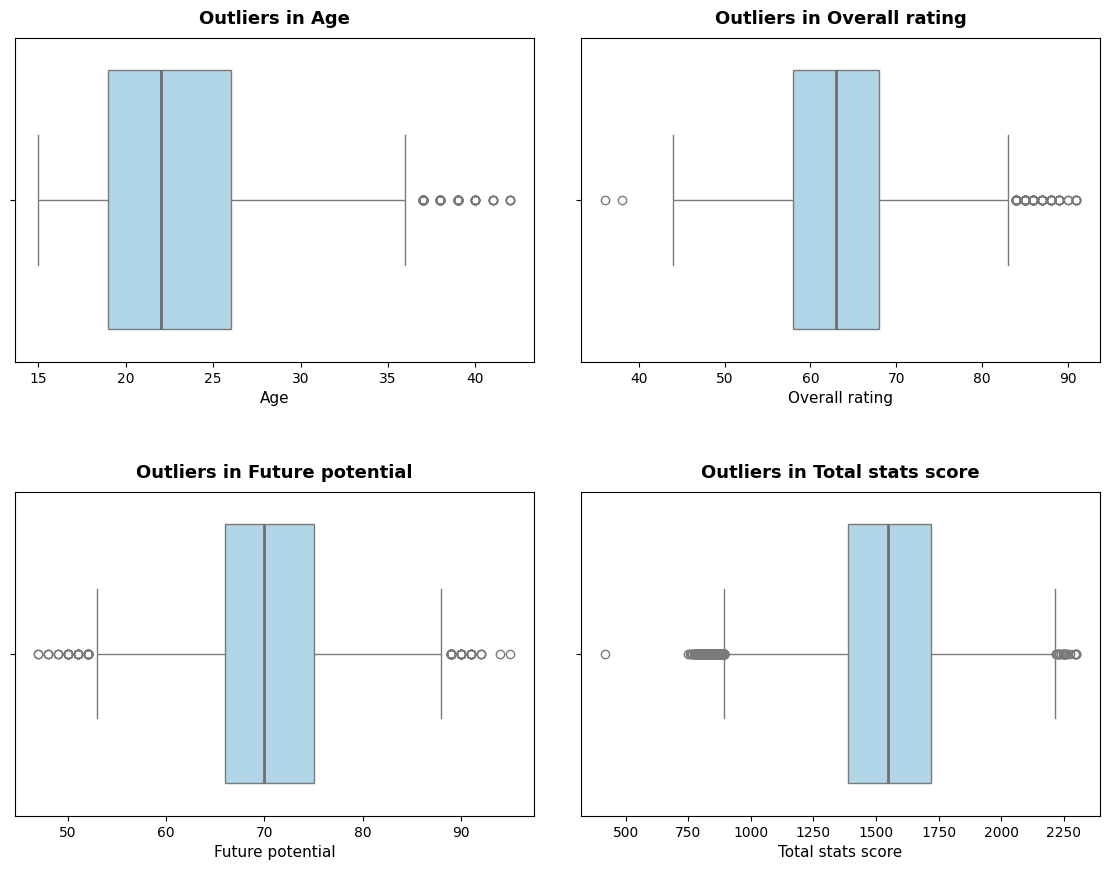

In [25]:
fig = plt.figure(figsize=(14, 16))
gs = gridspec.GridSpec(3, 4)

axes = [
    fig.add_subplot(gs[0, :2]),
    fig.add_subplot(gs[0, 2:]),
    fig.add_subplot(gs[1, :2]),
    fig.add_subplot(gs[1, 2:]),
]

baby_blue = "#A7D8F0"
gray = "#6E6E6E"

for i, col in enumerate(num_cols):
    sns.boxplot(
        x=train[col],
        color=baby_blue,
        ax=axes[i],
        medianprops={"color": gray, "linewidth": 2}
    )

    axes[i].set_title(f'Outliers in {col.capitalize().replace("_"," ")}', fontsize=13, weight='bold', pad=10)
    axes[i].set_xlabel(col.capitalize().replace("_"," "), fontsize=11)

plt.subplots_adjust(hspace=0.4)
plt.show()

In [26]:
for col in num_cols:
    lower_bound, upper_bound = bounds[col]

    train[col] = train[col].clip(lower=lower_bound, upper=upper_bound)
    test[col] = test[col].clip(lower=lower_bound, upper=upper_bound)

print("Train rows :", train.shape[0])

Train rows : 15733


# 3. Encode categorical columns



In [27]:
categorical_cols = ['Country', 'Team', 'Position']

enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

train_enc = enc.fit_transform(train[categorical_cols])
test_enc = enc.transform(test[categorical_cols])

train_enc_df = pd.DataFrame(train_enc, columns=enc.get_feature_names_out(categorical_cols), index=train.index)
test_enc_df = pd.DataFrame(test_enc, columns=enc.get_feature_names_out(categorical_cols), index=test.index)

train = pd.concat([train.drop(columns=categorical_cols), train_enc_df], axis=1)
test = pd.concat([test.drop(columns=categorical_cols), test_enc_df], axis=1)

print(f"Train shape : {train.shape}")
print(f"Test shape : {test.shape}")

Train shape : (15733, 1179)
Test shape : (3934, 1179)


In [28]:
train = train.drop(columns=['Name'])
test = test.drop(columns=['Name'])

In [29]:
print(train.dtypes)


Age                  float64
Overall_Rating       float64
Future Potential     float64
Value Per M$         float64
Total_Stats Score    float64
                      ...   
Position_RM          float64
Position_RW          float64
Position_RWB         float64
Position_ST          float64
Position_SW          float64
Length: 1178, dtype: object


In [30]:
train.head()

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score,Country_Afghanistan,Country_Albania,Country_Algeria,Country_Andorra,Country_Angola,...,Position_LM,Position_LW,Position_LWB,Position_RB,Position_RF,Position_RM,Position_RW,Position_RWB,Position_ST,Position_SW
7804,21.0,47.0,68.0,0.000,1085.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13909,27.0,62.0,63.0,0.475,1466.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
730,31.0,82.0,82.0,25.000,1971.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15311,26.0,64.0,67.0,0.675,1400.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5998,26.0,70.0,73.0,2.100,1974.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
train_unscaled = train.copy()
test_unscaled  = test.copy()

# 4. Scale numerical features

In [32]:
scaler = StandardScaler()
train[num_cols] = scaler.fit_transform(train[num_cols])
test[num_cols] = scaler.transform(test[num_cols])
print(f"Scaled features: {num_cols}")
print("Categorical features remained unchanged")

Scaled features: ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']
Categorical features remained unchanged


In [33]:
train.head()

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score,Country_Afghanistan,Country_Albania,Country_Algeria,Country_Andorra,Country_Angola,...,Position_LM,Position_LW,Position_LWB,Position_RB,Position_RF,Position_RM,Position_RW,Position_RWB,Position_ST,Position_SW
7804,-0.424271,-2.092082,-0.415141,0.000,-1.623164,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13909,0.868969,-0.157272,-1.188245,0.475,-0.253023,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
730,1.731130,2.422475,1.749551,25.000,1.563044,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15311,0.653429,0.100702,-0.569762,0.675,-0.490370,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5998,0.653429,0.874627,0.357963,2.100,1.573832,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Task 4 Polynomial Regression

In [34]:
y_train_lr = train['Value Per M$']
y_test_lr = test['Value Per M$']

X_train_lr = train.drop(columns=['Value Per M$'])
X_test_lr = test.drop(columns=['Value Per M$'])

In [35]:
def evaluate(model, X_tr, X_te, y_tr, y_te, name="Model"):
    tr_pred = model.predict(X_tr)
    te_pred = model.predict(X_te)
    results = {
        "Train MAE":  mean_absolute_error(y_tr, tr_pred),
        "Test  MAE":  mean_absolute_error(y_te, te_pred),
        "Train MSE":  mean_squared_error(y_tr, tr_pred),
        "Test  MSE":  mean_squared_error(y_te, te_pred),
        "Train RMSE": np.sqrt(mean_squared_error(y_tr, tr_pred)),
        "Test  RMSE": np.sqrt(mean_squared_error(y_te, te_pred)),
        "Train R2":   r2_score(y_tr, tr_pred),
        "Test  R2":   r2_score(y_te, te_pred),
    }
    print("\n" + "="*60)
    print(f"  {name}")
    print("="*60)
    for i, j in results.items():
        print(f"  {i:<13}: {j:.4f}")
    return results

In [36]:
lin_model = LinearRegression()
lin_model.fit(X_train_lr, y_train_lr)
linear_results = evaluate(lin_model, X_train_lr, X_test_lr, y_train_lr, y_test_lr,name="Baseline Linear Regression")


  Baseline Linear Regression
  Train MAE    : 2.3672
  Test  MAE    : 2.4915
  Train MSE    : 24.9029
  Test  MSE    : 23.2818
  Train RMSE   : 4.9903
  Test  RMSE   : 4.8251
  Train R2     : 0.5377
  Test  R2     : 0.5131


In [37]:
poly_results = []

num_cols = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']
degrees = [2, 3, 4,5]

for d in degrees:

    poly = PolynomialFeatures(degree=d, include_bias=False)

    X_train_num_poly = poly.fit_transform(X_train_lr[num_cols])
    X_test_num_poly = poly.transform(X_test_lr[num_cols])

    feature_names = poly.get_feature_names_out(num_cols)

    train_poly_df = pd.DataFrame(X_train_num_poly, columns=feature_names, index=X_train_lr.index)
    test_poly_df = pd.DataFrame(X_test_num_poly, columns=feature_names, index=X_test_lr.index)

    X_train_poly = pd.concat([X_train_lr.drop(columns=num_cols), train_poly_df], axis=1)
    X_test_poly = pd.concat([X_test_lr.drop(columns=num_cols), test_poly_df], axis=1)

    model = LinearRegression()
    model.fit(X_train_poly, y_train_lr)

    train_r2 = r2_score(y_train_lr, model.predict(X_train_poly))
    test_r2 = r2_score(y_test_lr, model.predict(X_test_poly))
    gap = train_r2 - test_r2

    poly_results.append({
        "degree": d,
        "train_r2": train_r2,
        "test_r2": test_r2,
        "gap": gap
    })

    print("\n" + "-"*50)
    print(f"Polynomial Degree = {d}")
    print("-"*50)
    print(f"Train R2 : {train_r2:.4f}")
    print(f"Test R2  : {test_r2:.4f}")
    print(f"Gap      : {gap:.4f}")


--------------------------------------------------
Polynomial Degree = 2
--------------------------------------------------
Train R2 : 0.7343
Test R2  : 0.7443
Gap      : -0.0099

--------------------------------------------------
Polynomial Degree = 3
--------------------------------------------------
Train R2 : 0.8637
Test R2  : 0.8825
Gap      : -0.0187

--------------------------------------------------
Polynomial Degree = 4
--------------------------------------------------
Train R2 : 0.9212
Test R2  : 0.8921
Gap      : 0.0291

--------------------------------------------------
Polynomial Degree = 5
--------------------------------------------------
Train R2 : 0.9408
Test R2  : 0.8828
Gap      : 0.0580


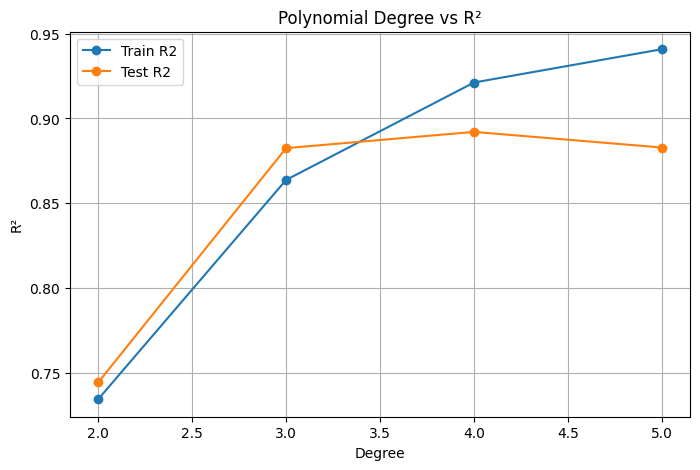

In [38]:
res_df = pd.DataFrame(poly_results)

plt.figure(figsize=(8,5))
plt.plot(res_df["degree"], res_df["train_r2"], marker='o', label="Train R2")
plt.plot(res_df["degree"], res_df["test_r2"], marker='o', label="Test R2")

plt.title("Polynomial Degree vs R²")
plt.xlabel("Degree")
plt.ylabel("R²")
plt.legend()
plt.grid()
plt.show()

## Polynomial Degree Analysis

### Observed Trend
As the polynomial degree increases, both Train and Test R² improve significantly
from Degree 2 to Degree 4, showing that the model is capturing more complex
relationships in the data.

However, after Degree 4, the model starts showing signs of overfitting:

- **Degree 2:** The model provides a reasonable fit with Train and Test R²
  around 0.74 and a negligible gap, indicating good generalization.
- **Degree 3:** Both Train and Test R² improve substantially, reaching
  approximately 0.86 and 0.88 respectively, while maintaining a very small gap.
- **Degree 4:** The model achieves the highest Test R² (0.8921), suggesting
  the best predictive performance. The train-test gap remains relatively small
  (0.029), indicating only mild overfitting.
- **Degree 5:** Train R² continues to increase (0.9408), but Test R² drops
  slightly compared to Degree 4, while the gap nearly doubles (0.058),
  indicating stronger overfitting.

---

### Results Summary

| Degree | Train R² | Test R² | Gap |
|---------|----------|----------|----------|
| 2 | 0.7343 | 0.7443 | -0.0099 |
| 3 | 0.8637 | 0.8825 | -0.0187 |
| 4 | 0.9212 | 0.8921 | 0.0291 |
| 5 | 0.9408 | 0.8828 | 0.0580 |

---

### Best Generalization: Degree 4

**Degree 4** provides the best overall performance because:

- It achieves the **highest Test R² (0.8921)** among all tested models.
- The train-test gap (**0.0291**) remains reasonably small, suggesting that
  the model still generalizes well to unseen data.
- Compared with Degree 5, it offers better predictive performance while
  exhibiting less overfitting.

### Overfitting Observation

The increase from Degree 4 to Degree 5 results in:

- Higher Train R² (0.9212 → 0.9408).
- Lower Test R² (0.8921 → 0.8828).
- A larger train-test gap (0.0291 → 0.0580).

This indicates that Degree 5 begins to memorize training data rather than
learning patterns that generalize well.

> **Conclusion:** Degree 4 is selected as the optimal polynomial degree because
> it achieves the highest predictive performance while maintaining acceptable
> generalization. Regularization techniques such as Ridge and Lasso can be
> applied to further reduce overfitting and improve model robustness.

"Degree 4 was selected for regularization as it achieves the highest Test R² (0.892) but shows signs of overfitting (gap = 0.029). Ridge and Lasso are applied to control this overfitting."

In [39]:
best_row = res_df.loc[res_df["test_r2"].idxmax()]
best_degree = int(best_row["degree"])

print("Best Degree:", best_degree)
print(best_row)

Best Degree: 4
degree      4.000000
train_r2    0.921171
test_r2     0.892051
gap         0.029120
Name: 2, dtype: float64


In [40]:
poly = PolynomialFeatures(degree=best_degree, include_bias=False)

X_train_num_poly = poly.fit_transform(X_train_lr[num_cols])
X_test_num_poly = poly.transform(X_test_lr[num_cols])

feature_names = poly.get_feature_names_out(num_cols)

train_poly_df = pd.DataFrame(X_train_num_poly, columns=feature_names, index=X_train_lr.index)
test_poly_df = pd.DataFrame(X_test_num_poly, columns=feature_names, index=X_test_lr.index)

X_train_final = pd.concat([X_train_lr.drop(columns=num_cols), train_poly_df], axis=1)
X_test_final = pd.concat([X_test_lr.drop(columns=num_cols), test_poly_df], axis=1)

In [41]:
scaler = StandardScaler()

X_train_final = scaler.fit_transform(X_train_final)
X_test_final = scaler.transform(X_test_final)

In [42]:
alphas = np.logspace(-3, 6, 50)
ridge_results = []

for a in alphas:
    model = Ridge(alpha=a)
    model.fit(X_train_final, y_train_lr)

    ridge_results.append({
        "alpha": a,
        "train_rmse": np.sqrt(mean_squared_error(y_train_lr, model.predict(X_train_final))),
        "test_rmse": np.sqrt(mean_squared_error(y_test_lr, model.predict(X_test_final)))
    })

ridge_df = pd.DataFrame(ridge_results)
best_ridge = ridge_df.loc[ridge_df["test_rmse"].idxmin()]


for _, row in ridge_df.iterrows():
    print(f"Alpha: {row['alpha']:.5f} | Train RMSE: {row['train_rmse']:.4f} | Test RMSE: {row['test_rmse']:.4f}")

print(f"\nBest Ridge α = {best_ridge['alpha']:.5f} | Test RMSE = {best_ridge['test_rmse']:.4f}")

Alpha: 0.00100 | Train RMSE: 2.0608 | Test RMSE: 2.2709
Alpha: 0.00153 | Train RMSE: 2.0608 | Test RMSE: 2.2704
Alpha: 0.00233 | Train RMSE: 2.0608 | Test RMSE: 2.2695
Alpha: 0.00356 | Train RMSE: 2.0608 | Test RMSE: 2.2683
Alpha: 0.00543 | Train RMSE: 2.0608 | Test RMSE: 2.2664
Alpha: 0.00829 | Train RMSE: 2.0608 | Test RMSE: 2.2636
Alpha: 0.01265 | Train RMSE: 2.0608 | Test RMSE: 2.2594
Alpha: 0.01931 | Train RMSE: 2.0608 | Test RMSE: 2.2534
Alpha: 0.02947 | Train RMSE: 2.0608 | Test RMSE: 2.2450
Alpha: 0.04498 | Train RMSE: 2.0608 | Test RMSE: 2.2332
Alpha: 0.06866 | Train RMSE: 2.0609 | Test RMSE: 2.2173
Alpha: 0.10481 | Train RMSE: 2.0610 | Test RMSE: 2.1964
Alpha: 0.15999 | Train RMSE: 2.0611 | Test RMSE: 2.1696
Alpha: 0.24421 | Train RMSE: 2.0614 | Test RMSE: 2.1367
Alpha: 0.37276 | Train RMSE: 2.0618 | Test RMSE: 2.0979
Alpha: 0.56899 | Train RMSE: 2.0623 | Test RMSE: 2.0550
Alpha: 0.86851 | Train RMSE: 2.0632 | Test RMSE: 2.0100
Alpha: 1.32571 | Train RMSE: 2.0644 | Test RMSE:

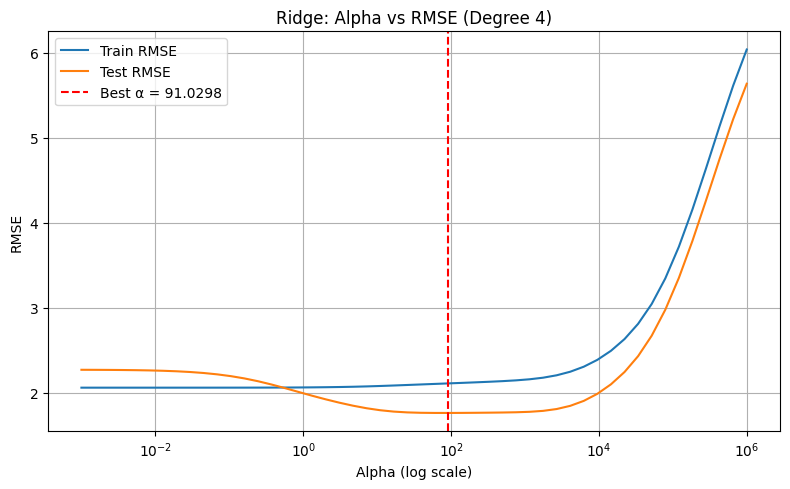

Best Ridge α = 91.02982 | Test RMSE = 1.7635


In [43]:
plt.figure(figsize=(8, 5))
plt.plot(ridge_df["alpha"], ridge_df["train_rmse"], label="Train RMSE")
plt.plot(ridge_df["alpha"], ridge_df["test_rmse"], label="Test RMSE")
plt.axvline(best_ridge["alpha"], color="red", linestyle="--",
            label=f"Best α = {best_ridge['alpha']:.4f}")
plt.xscale("log")
plt.title("Ridge: Alpha vs RMSE (Degree 4)")
plt.xlabel("Alpha (log scale)")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Best Ridge α = {best_ridge['alpha']:.5f} | Test RMSE = {best_ridge['test_rmse']:.4f}")

In [ ]:
alphas = np.logspace(-3, 6, 50)
lasso_results = []

for a in alphas:
    model = Lasso(alpha=a, max_iter=10000)
    model.fit(X_train_final, y_train_lr)

    lasso_results.append({
        "alpha": a,
        "train_rmse": np.sqrt(mean_squared_error(y_train_lr, model.predict(X_train_final))),
        "test_rmse": np.sqrt(mean_squared_error(y_test_lr, model.predict(X_test_final)))
    })

lasso_df = pd.DataFrame(lasso_results)
best_lasso = lasso_df.loc[lasso_df["test_rmse"].idxmin()]

# Report RMSE for each alpha
for _, row in lasso_df.iterrows():
    print(f"Alpha: {row['alpha']:.5f} | Train RMSE: {row['train_rmse']:.4f} | Test RMSE: {row['test_rmse']:.4f}")

print(f"\nBest Lasso α = {best_lasso['alpha']:.5f} | Test RMSE = {best_lasso['test_rmse']:.4f}")



In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(lasso_df["alpha"], lasso_df["train_rmse"], label="Train RMSE")
plt.plot(lasso_df["alpha"], lasso_df["test_rmse"], label="Test RMSE")
plt.axvline(best_lasso["alpha"], color="red", linestyle="--",
            label=f"Best α = {best_lasso['alpha']:.4f}")
plt.xscale("log")
plt.title("Lasso: Alpha vs RMSE (Degree 4)")
plt.xlabel("Alpha (log scale)")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
best_lasso_model = Lasso(alpha=best_lasso["alpha"], max_iter=10000)
best_lasso_model.fit(X_train_final, y_train_lr)

feature_names   = best_poly.get_feature_names_out(num_cols)
zeroed_mask     = best_lasso_model.coef_ == 0
zeroed_features = feature_names[zeroed_mask]
active_features = feature_names[~zeroed_mask]

print(f"Total features  : {len(feature_names)}")
print(f"Zeroed features : {zeroed_mask.sum()}")
print(f"Active features : {(~zeroed_mask).sum()}")

print("\nZeroed features:")
for f in zeroed_features:
    print(f"  - {f}")

print("\nActive features:")
for f in active_features:
    print(f"  + {f}")


Number of zeroed features by Lasso: 764
